### EDA Objective
The goal of this EDA is to:
1. Identify variables associated with default risk
2. Understand how default probability changes across feature segments
3. Detect non-linear relationships and risk thresholds
4. Inform feature engineering and model choice


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Users/Pratik/DS/credit-risk-ml/data/raw/application_train.csv')

In [3]:
df.shape

(307511, 122)

In [4]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


###  Target Distribution

Before analyzing individual features, it is important to understand the distribution of the target variable.

In credit risk datasets, defaults typically represent a small fraction of observations.
This imbalance impacts:
- Model evaluation metrics
- Threshold selection
- Feature interpretability




In [6]:
target = df['TARGET']

In [7]:
df['TARGET'].value_counts(normalize=True)*100 # Checking Class Imbalance

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

### Observation
- The dataset is heavily imbalanced, with defaults forming a minority class.
- Accuracy alone will not be a suitable evaluation metric.
- Metrics such as ROC-AUC, Precision-Recall, and calibrated probabilities will be more informative.


In [8]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [10]:
df.sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
48414,156066,0,Cash loans,M,N,N,0,202500.0,719946.0,34767.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,2.0
40714,147152,0,Cash loans,F,Y,Y,3,202500.0,654498.0,33547.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
127083,247381,0,Cash loans,F,Y,Y,0,225000.0,360000.0,21874.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
216545,350912,0,Cash loans,F,N,Y,0,202500.0,640080.0,29839.5,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
23400,127229,0,Cash loans,F,Y,Y,0,157500.0,927252.0,27112.5,...,0,0,0,0,0.0,0.0,0.0,4.0,4.0,3.0


### Dataset Overview

- Each row represents a loan application
- `TARGET = 1` indicates the applicant defaulted on the loan
- `TARGET = 0` indicates the applicant repaid successfully

The dataset contains a mix of:
- Numerical financial and demographic variables
- High-cardinality categorical features
- Engineered time-based fields (e.g., days since birth, employment)

Credit default is a **rare event**, so class imbalance is expected and must be handled carefully.

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
print(len(num_cols),'\n')
cat_col = df.select_dtypes(include=object).columns
print(len(cat_col),'\n',cat_col)


106 

16 
 Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


### Numerical Features vs Default Risk

For numerical variables, linear correlation with the target is often weak in credit risk datasets.
Instead, we focus on:
- Distributional differences between defaulters and non-defaulters
- Presence of non-linear or threshold-based effects
- Outliers and skewness


In [ ]:
df['DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
           ...  
-11471         1
-12878         1
-10573         1
-12990         1
-14184         1
Name: count, Length: 12574, dtype: int64

365243 is used as a placeholder for missing value.

#### Income Distribution by Default Status

Income is a key indicator of repayment capacity, but its relationship with default risk is typically non-linear.

A log scale is used due to heavy right skew and extreme outliers.


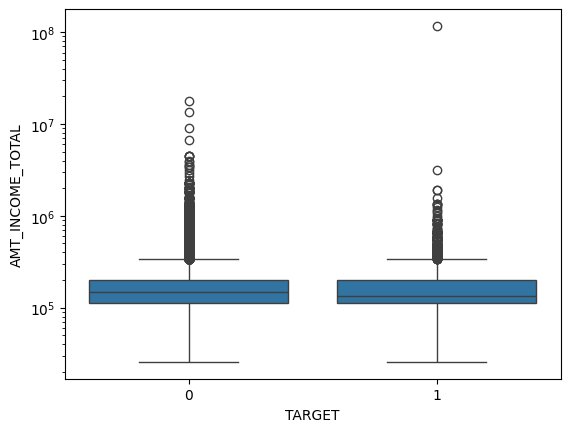

In [20]:
sns.boxplot(
    data=df,
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    )   
plt.yscale('log')

#### Observation
- Median income is similar across default and non-default groups.
- However, default rates vary across income bands rather than linearly.
- This suggests income is more useful when transformed or binned, rather than used raw.


#### Age Distribution by Default Status

Age is represented as negative days since birth.
Older applicants generally exhibit lower default risk.


C:\Users\Pratik\AppData\Local\Temp\ipykernel_21228\944797294.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bin')['TARGET'].mean().plot(kind='line')


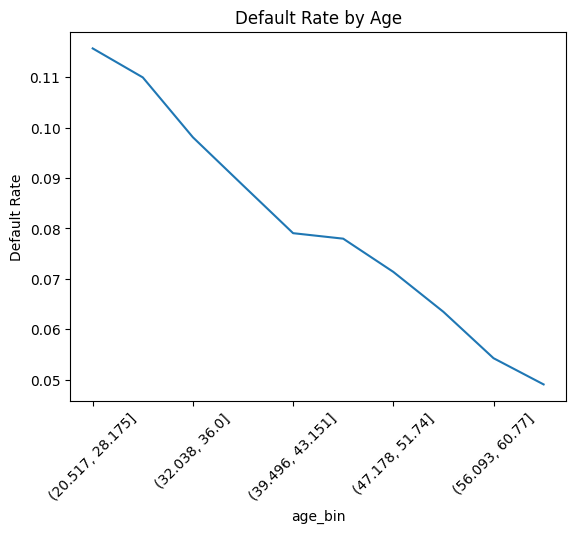

In [32]:
df['age_years'] = -df['DAYS_BIRTH'] / 365
df['age_bin'] = pd.qcut(df['age_years'], 10)

df.groupby('age_bin')['TARGET'].mean().plot(kind='line')
plt.ylabel("Default Rate")
plt.title("Default Rate by Age")
plt.xticks(rotation=45)
plt.show()

#### Observation
- Defaulters tend to be younger on average.
- The separation is not extreme, but consistent.
- Age may interact with other variables such as income and employment length.


#### Default Rate Across Income Bands

To better capture non-linear effects, income is binned into discrete ranges and default rates are calculated per bin.


C:\Users\Pratik\AppData\Local\Temp\ipykernel_21228\1019774048.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_bin')['TARGET'].mean().plot(kind='bar')


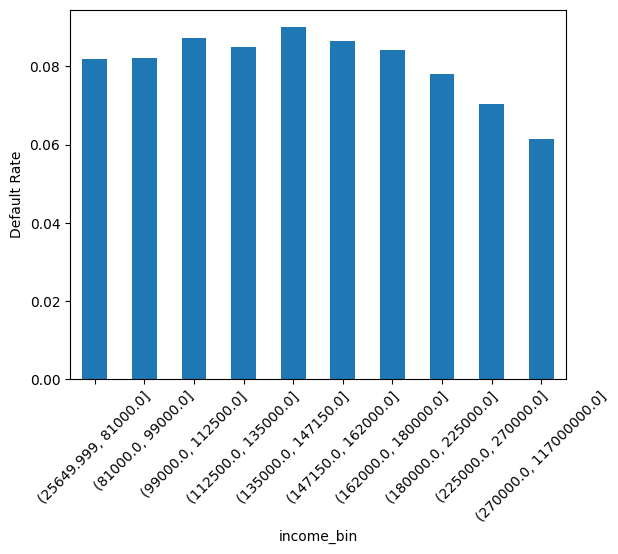

In [33]:
df['income_bin'] = pd.qcut(df['AMT_INCOME_TOTAL'], 10)
df.groupby('income_bin')['TARGET'].mean().plot(kind='bar')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

#### Observation
- Default rate decreases as income increases.
- The relationship is monotonic but not linear.
- This confirms that income is an important risk driver despite low raw correlation.


### Categorical Features and Default Risk

Categorical variables are analyzed by computing default rates per category.
This approach is more informative than correlation encoding for categorical features.


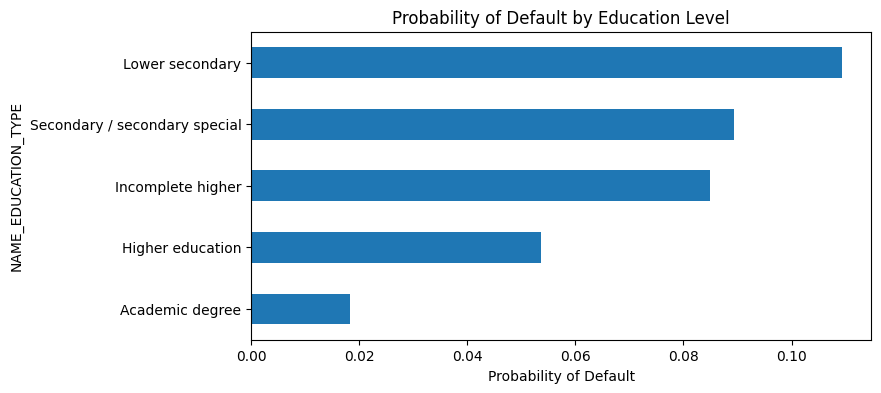

In [23]:
edu_type =df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()
edu_type.plot(kind='barh', figsize=(8, 4))
plt.xlabel('Probability of Default')
plt.title('Probability of Default by Education Level')
plt.show()

#### Observation
- Lower education levels are associated with higher default rates.
- Academic and higher education groups exhibit significantly lower default risk.
- Education level appears to have ordinal structure and may benefit from ordinal encoding.


In [24]:
edu_stats = df.groupby('NAME_EDUCATION_TYPE').agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'size')
).sort_values('default_rate')

edu_stats

,default_rate,count
NAME_EDUCATION_TYPE,,
Academic degree,0.018293,164
Higher education,0.053551,74863
Incomplete higher,0.084850,10277
Secondary / secondary special,0.089399,218391
Lower secondary,0.109277,3816


Categories with very low default rates (e.g., Academic degree) also have smaller sample sizes, which should be treated with caution.

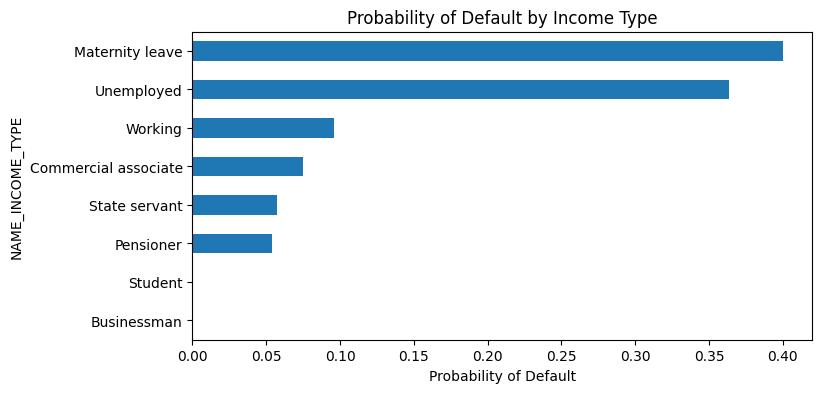

In [25]:
inc_type = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values()
inc_type.plot(kind='barh',figsize=(8,4))
plt.xlabel('Probability of Default')
plt.title('Probability of Default by Income Type')
plt.show()

Unemployed people, People on maternity leave have a higher chance of default,

In [26]:
inc_stats = df.groupby('NAME_INCOME_TYPE').agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'size')
).sort_values('default_rate')
inc_stats

,default_rate,count
NAME_INCOME_TYPE,,
Businessman,0.000000,10
Student,0.000000,18
Pensioner,0.053864,55362
State servant,0.057550,21703
Commercial associate,0.074843,71617
Working,0.095885,158774
Unemployed,0.363636,22
Maternity leave,0.400000,5


The sample set for Unemployed & Maternity leave is very low, this should be treated with causion.

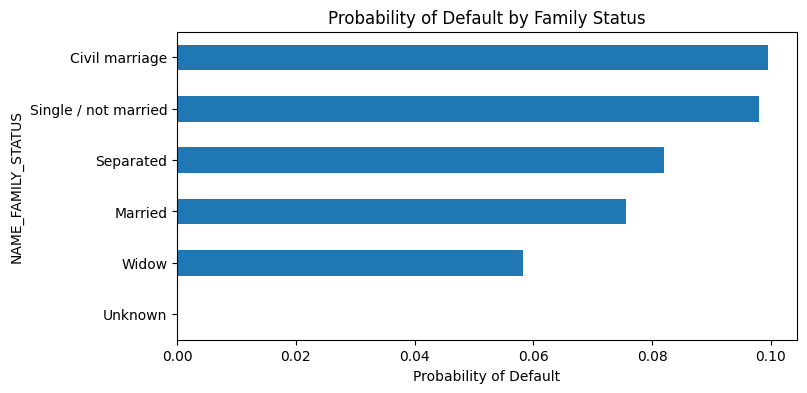

In [27]:
family_status = df.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values()
family_status.plot(kind='barh',figsize=(8,4))
plt.xlabel('Probability of Default')
plt.title('Probability of Default by Family Status')
plt.show()

In [28]:
family_stats = df.groupby('NAME_FAMILY_STATUS').agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'size')
).sort_values('default_rate')
family_stats

,default_rate,count
NAME_FAMILY_STATUS,,
Unknown,0.000000,2
Widow,0.058242,16088
Married,0.075599,196432
Separated,0.081942,19770
Single / not married,0.098077,45444
Civil marriage,0.099446,29775


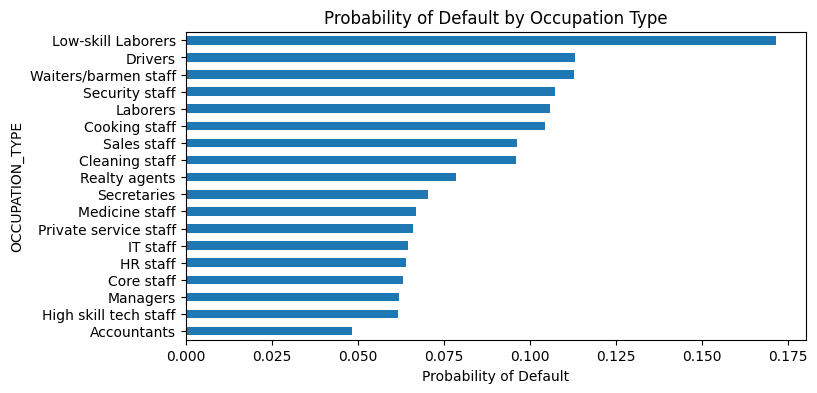

In [29]:
occupation_type = df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values()
occupation_type.plot(kind='barh',figsize=(8,4))
plt.xlabel('Probability of Default')
plt.title('Probability of Default by Occupation Type')
plt.show()

In [30]:
occupation_stats = df.groupby('OCCUPATION_TYPE').agg(
    default_rate=('TARGET', 'mean'),
    count=('TARGET', 'size')
).sort_values('default_rate')
occupation_stats

,default_rate,count
OCCUPATION_TYPE,,
Accountants,0.048303,9813
High skill tech staff,0.061599,11380
Managers,0.062140,21371
Core staff,0.063040,27570
HR staff,0.063943,563
IT staff,0.064639,526
Private service staff,0.065988,2652
Medicine staff,0.067002,8537
Secretaries,0.070498,1305


In [14]:
cardinality = (
    df[cat_col]
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

cardinality

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
dtype: int64

In [15]:
df['OCCUPATION_TYPE'].unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', nan,
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

In [16]:
df['ORGANIZATION_TYPE'].unique()

array(['Business Entity Type 3', 'School', 'Government', 'Religion',
       'Other', 'XNA', 'Electricity', 'Medicine',
       'Business Entity Type 2', 'Self-employed', 'Transport: type 2',
       'Construction', 'Housing', 'Kindergarten', 'Trade: type 7',
       'Industry: type 11', 'Military', 'Services', 'Security Ministries',
       'Transport: type 4', 'Industry: type 1', 'Emergency', 'Security',
       'Trade: type 2', 'University', 'Transport: type 3', 'Police',
       'Business Entity Type 1', 'Postal', 'Industry: type 4',
       'Agriculture', 'Restaurant', 'Culture', 'Hotel',
       'Industry: type 7', 'Trade: type 3', 'Industry: type 3', 'Bank',
       'Industry: type 9', 'Insurance', 'Trade: type 6',
       'Industry: type 2', 'Transport: type 1', 'Industry: type 12',
       'Mobile', 'Trade: type 1', 'Industry: type 5', 'Industry: type 10',
       'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
       'Industry: type 13', 'Trade: type 4', 'Telecom',
       'I

### EDA Summary & Key Observations

 The target variable is highly imbalanced, with default rates around 8–9%, which is typical for real-world credit risk datasets.
- Income-related features show heavy right skew and extreme outliers, making log transformation necessary.
- Higher income does not guarantee lower default risk, indicating that income alone is insufficient to assess creditworthiness.
- Age-related features (DAYS_BIRTH) show clear separation between defaulters and non-defaulters, suggesting strong predictive value.
- Many features exhibit non-linear relationships with the target, limiting the usefulness of simple correlation analysis.
- Feature importance and interactions are better captured using multivariate models rather than univariate EDA.
